First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Model Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



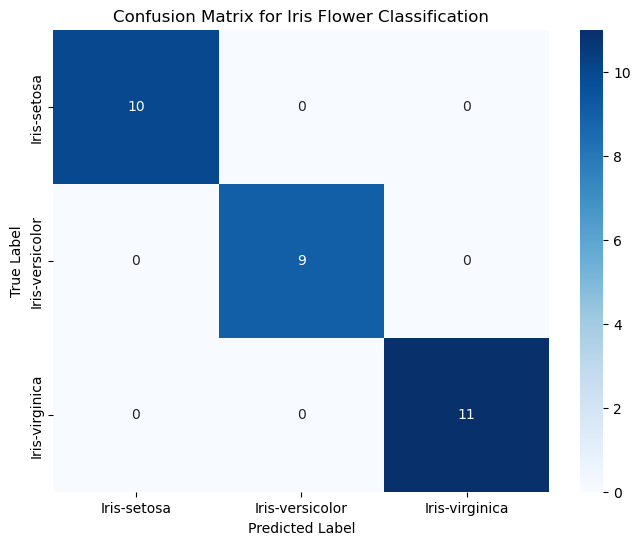

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
# Assuming the file is unzipped and in the same directory as the script.
# If you are reading directly from the zip extraction, make sure the path is correct.
df = pd.read_csv('IRIS.csv')

# Display the first few rows to verify the data
print("First 5 rows of the dataset:")
print(df.head())

# 2. Data Preprocessing
# The dataset has columns: 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'
X = df.drop('species', axis=1) # Features (Sepal & Petal measurements)
y = df['species']              # Target Variable (The species to predict)

# 3. Split the data into Training and Testing sets
# We use 80% of the data to train the model and 20% to test its accuracy.
# Setting random_state=42 ensures reproducibility so you get the exact same results every time.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Machine Learning Model
# Random Forest is highly accurate and handles non-linear relationships well.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Data
y_pred = model.predict(X_test)

# 6. Evaluate the Model's Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Optional: Visualize the Confusion Matrix to see exact correct/incorrect classifications
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Flower Classification')
plt.show()